Обозначения задачи $\psi$ -- угол ориентации машины относительно горизонтали, $\beta$ -- направление движения машины относительно ее ориентации (отличен от нуля при ненулевом повороте руля $\text{frontAngle}$). Положение центра машины задается координатами $x$ и $y$ и скоростью $v$. Управление осущетсвляется путем задания ускорения $a$ и скоростью поворота руля $s$.


## Организация перестроения

При перестроении я использовал закон управления, задающий дифференциальное уравнение (приближенные равенства справедливы на малых углах)
$$\boxed{
    \dot{\beta} \approx s = - c_1 \beta - c_2 \left(\psi - \text{arctan} \frac{y - y_\text{new}}{x - x_{\text{new}}} \right) - c_3 (y - y_\text{new}) + \text{regularisers},
    }
$$
где точка означает производную по времени.
При этом закон изменения ориентации машины $\psi$
$$
    \dot{\psi} = \frac{v}{w/2} \sin \beta \approx \frac{2 v}{w} \beta,
$$
так что в итоге закон изменения $\psi$:
$$
    \ddot{\psi} \approx -c_1 \dot{\psi} - c_2 (\psi - \psi_{\text{equilibrium}}) + \text{extra force},
$$
что соответсвует диф. уравнению гармонического осциллятора с трением.

Рассмотрим такое уравнение в отсутствие внешней силы и с положением равновесия в нуле:
$$
    \ddot{x} + 2 \gamma \dot{x} + \omega_0^2 x = 0. 
$$
его решения устроены как
$$
    x = \text{Re} \, A \exp\left(-\gamma t \pm i \sqrt{\omega_0^2 - \gamma^2} \right)
$$
В случае, когда $\gamma \gtrsim \omega_0$ решение стремится к 0 достаточно быстро. (При $\gamma < \omega_0$ возникают нежелательные осцилляции, а при нулевой или маленькой $\omega_0$ функция выходит не на $0$ или выходит недостаточно быстро). Это проиллюстрировано на графиках:

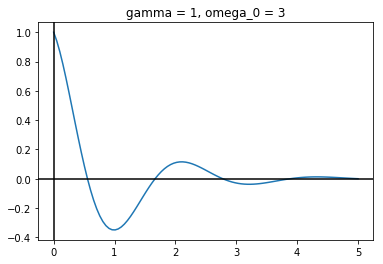

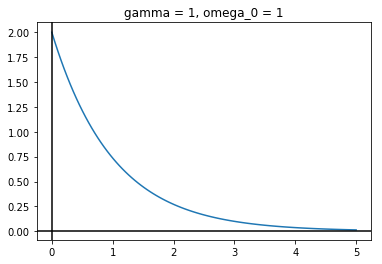

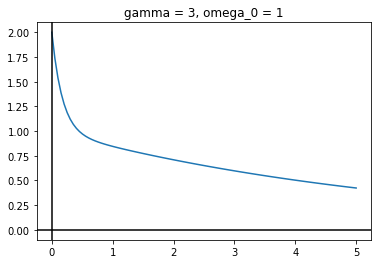

In [19]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def plot(gamma, omega_0):
    t = np.linspace(0, 5, 100)
    if omega_0 > gamma:
        x = np.exp(- gamma * t) * np.cos(np.sqrt(omega_0**2 - gamma**2) * t)
    else:
        x = np.exp(- gamma * t - np.sqrt(gamma**2 - omega_0**2) * t) + np.exp(- gamma * t + np.sqrt(gamma**2 - omega_0**2) * t)

    fig, ax = plt.subplots()
    plt.plot(t, x)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.title('gamma = {}, omega_0 = {}'.format(gamma, omega_0))
    plt.show()

plot(1, 3)
plot(1, 1)
plot(3, 1)

Таким образом, оптимальным является выбор $\gamma \approx \omega_0$. Тогда подбирая константы $c_1$, $c_2$, $c_3$ в первом (обведенном в рамку) уравнении можно добиться адекватного поведения.

## Построение маршрута

Для построения маршрута я выбирал три ближайших препятствия, для каждого рассматривал три варианта прохождения: сверху в середине интервала, снизу в середине интервала и горизонтальное движение. Из этих траекторий отбирал те, на которых не происходит столкновения, а из оставшихся выбирал ту, у которой минимальный максимальный наклон.

## Эвристики

Также я использовал набор эвристик, например
- снижение скорости перед крутыми поворотами
- снижение скорости при опасном приближении к краю дороги
- снижение скорости при больших углах поворота руля и ориентации машины
- проверка того, что тормозной путь меньше расстояния до пешеходных переходов, следующих за ближайшим
- если два пешеходных перехода расположены рядом, то они рассматриваются как один большой (слишком опасно останваливаться между ними, если промежуток узкий, можно все равно зацепить пешехода)